In [1]:
import evident
from evident.plotting import plot_power_curve
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

from utils.data_processing import process_string

plt.rcParams["font.family"] = "Arial"
%matplotlib inline

In [2]:
meta = pd.read_csv("../../data/fay_meta_diets.csv", index_col=0)
meta["antibiotics_treatment"] = meta["antibiotics_treatment"].astype(str)
meta["PDI_Quintile"] = meta["PDI_Quintile"].astype(str)
meta["hPDI_Quintile"] = meta["hPDI_Quintile"].astype(str)

# Power Analysis

## Overview
We examine statistical power (1 - β) across different sample sizes to determine the minimum cohort size needed to reliably detect observed effect sizes.

## Analysis Details
- Tests multiple significance levels (α):
  - 0.05 (conventional)
  - 0.01 (stringent)
  - 0.001 (highly stringent)
- Evaluates power against 0.8 threshold (conventional requirement)
- Generates power curves to visualize sample size requirements

## Interpretation
The resulting curves help determine the minimum sample size needed to achieve adequate statistical power, informing future study designs and validating current sample sizes.


In [3]:
diversity = "shannon_entropy"  # "observed_features" #"shannon_entropy" #"faith_pd"

with warnings.catch_warnings():
    warnings.filterwarnings("ignore")
    adh = evident.UnivariateDataHandler(
        meta[diversity], meta, max_levels_per_category=6
    )

EffectSizeResult(effect_size=0.1619442058534713, metric='cohens_f', column='age_group')
          shannon_entropy                    
                    count      mean       std
age_group                                    
18-34                 411  6.134112  0.513311
35-49                 360  6.280281  0.543956
50-64                 179  6.342966  0.528496
65+                    23  6.320609  0.601676


<AxesSubplot: xlabel='Total Observations', ylabel='Power (1 - $\\beta$)'>

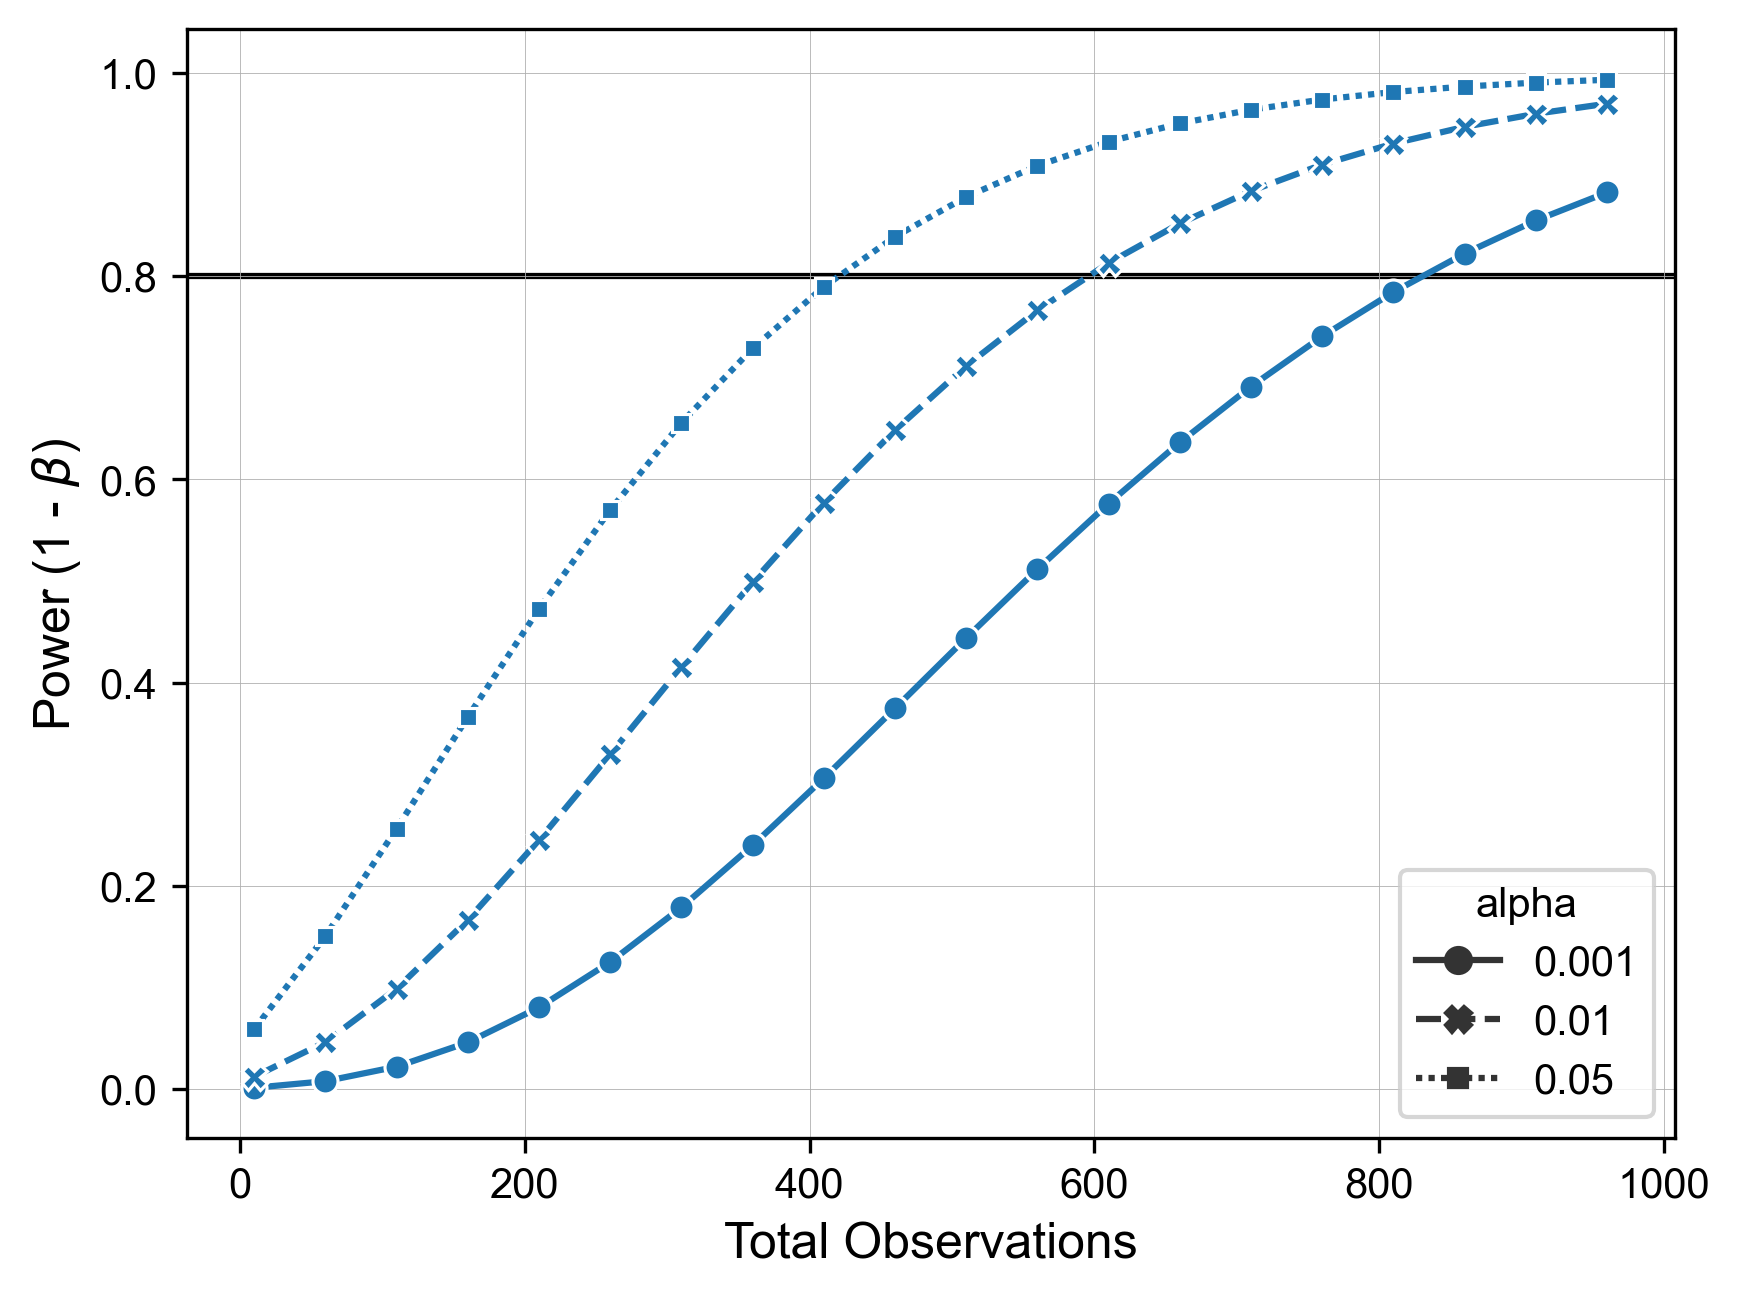

In [4]:
feature = "age_group"

print(adh.calculate_effect_size(column=feature))
print(meta.groupby(feature).agg({diversity: ["count", "mean", "std"]}))

#### Plotting the power curve ####
alpha_vals = [0.05, 0.01, 0.001]
obs_vals = np.arange(10, 1001, step=50)
results = adh.power_analysis(feature, alpha=alpha_vals, total_observations=obs_vals)

plot_power_curve(results, target_power=0.8, style="alpha", markers=True)

# Effect Size Analysis Results

The plots show the effect sizes of different categorical variables on three alpha diversity metrics:

1. Observed Features: Raw count of unique species/features detected
2. Shannon Entropy: Measure of both richness and evenness of species distribution
3. Faith's Phylogenetic Diversity (PD): Incorporates phylogenetic relationships between species

Key findings:
- Antibiotics treatment shows the strongest effect across all diversity metrics
- Language and HEI quartile also demonstrate notable effects
- Demographic factors like age group and smoking status show moderate effects
- Factors like gender and DASH quartile show minimal impact on diversity

The effect sizes are measured using Cohen's d for binary variables and Cohen's f for categorical variables with >2 levels.


In [5]:
from evident.effect_size import effect_size_by_category

meta_categ_cols = [
    "gender",
    "smoking",
    "health_state",
    "antibiotics_treatment",
    "cohort",
    "bmi_cat",  #'income', 'education',
    "age_group",
    "swiss_citizen",
    "urbanity",
    "language",
    "batch",
    "diet_restriction",
    "is_menopaused",
    "HEI_Quartile",
    "DASH_Quartile",
    "PDI_Quintile",
    "hPDI_Quintile",
]

evires_effect_by_categ = effect_size_by_category(adh, meta_categ_cols, n_jobs=2)

evires_effect_by_categ.to_dataframe().sort_values("effect_size", ascending=False)

,effect_size,metric,column
0,0.292690,cohens_d,antibiotics_treatment
1,0.277640,cohens_d,language
5,0.257616,cohens_f,HEI_Quartile
6,0.231516,cohens_f,batch
7,0.161944,cohens_f,age_group
8,0.161127,cohens_f,hPDI_Quintile
9,0.153803,cohens_f,smoking
2,0.141349,cohens_d,is_menopaused
10,0.125974,cohens_f,bmi_cat
3,0.105883,cohens_d,cohort


In [6]:
evires_list = []

for diversity in ["observed_features", "shannon_entropy", "faith_pd"]:
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore")
        adh = evident.UnivariateDataHandler(
            meta[diversity], meta, max_levels_per_category=6
        )

    evires_effect_by_categ = effect_size_by_category(adh, meta_categ_cols, n_jobs=2)

    evires = evires_effect_by_categ.to_dataframe().sort_values(
        "effect_size", ascending=False
    )
    evires["diversity"] = diversity
    evires["column"] = evires["column"].apply(process_string)

    evires_list.append(evires)

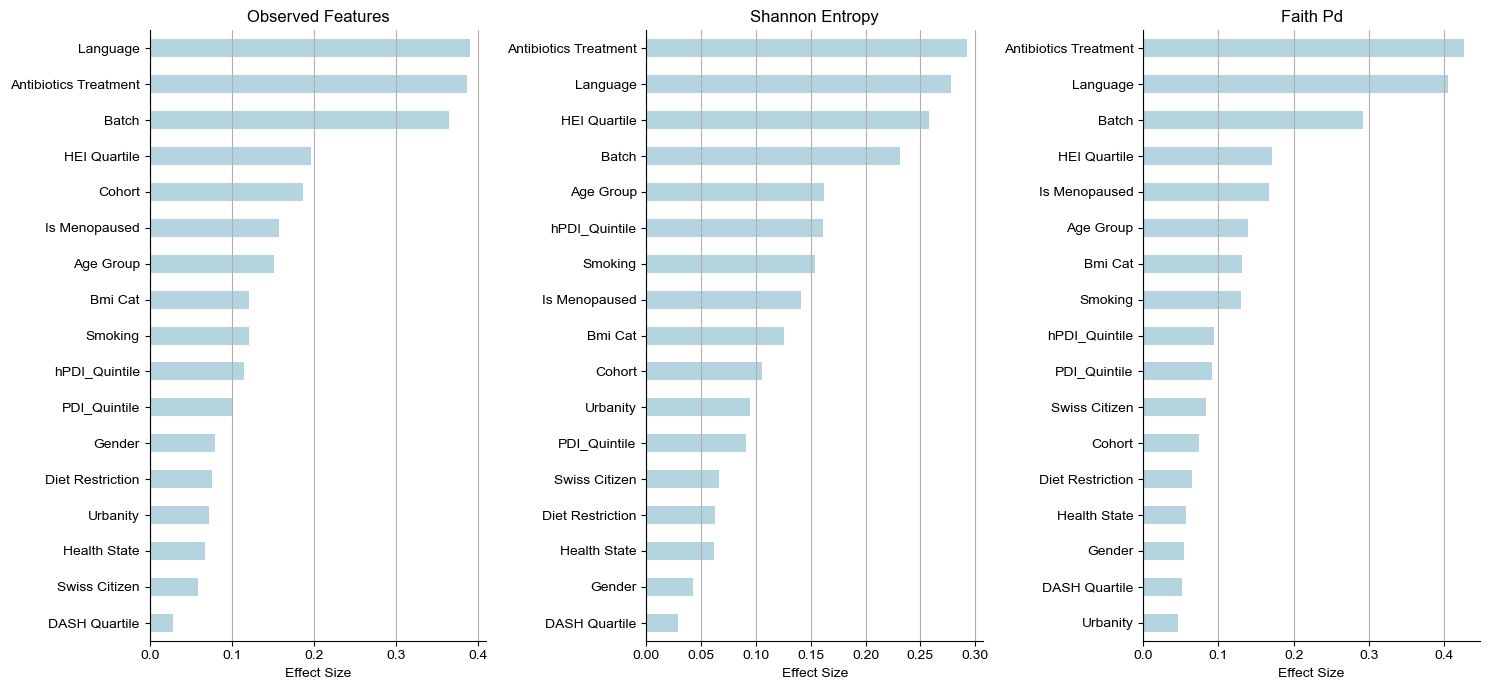

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(15, 7), sharey=False)
for i, diversity in enumerate(["observed_features", "shannon_entropy", "faith_pd"]):
    sns.barplot(
        data=evires_list[i],
        x="effect_size",
        y="column",
        color="lightblue",
        ax=ax[i],
        width=0.5,
    )
    ax[i].set_title(process_string(diversity))
    ax[i].set_xlabel("Effect Size")
    ax[i].set_ylabel("")
    ax[i].grid(axis="x")  ## vertical gridlines

plt.tight_layout()
sns.despine()

## Pairwise Effect Size Analysis

Calculates effect sizes between extreme pairs of groups (e.g., obese vs. normal BMI, Q1 vs Q4 HEI quartile) within categorical variables

In [8]:
def effect_size_pairwise(
    metadata,
    feature,
    groups,
    univariate,
    max_levels_per_category=6,
):
    """
    Calculate the effect size for a given feature and groups of a categorical variable.

    Parameters:
    - metadata: pandas.DataFrame containing the metadata.
    - feature: String, the name of the categorical variable.
    - groups: List of strings, the groups to compare.
    - univariate: String, the name of the numerical variable to compare.
    - max_levels_per_category: Integer, the maximum number of levels to consider for the categorical variable.
    - datahandler: String, the type of data handler to use. Either "univariate" or "multivariate".
    - create_quartiles: Boolean, whether to create quartiles for the numerical variable.

    Returns:
    - A dictionary with the effect size and the confidence interval.
    """

    subset = metadata[metadata[feature].isin(groups)]
    datahandler = evident.UnivariateDataHandler(
        subset[univariate],
        subset[[feature, univariate]],
        max_levels_per_category=max_levels_per_category,
    )

    res = datahandler.calculate_effect_size(column=feature).to_dict()
    res["num"] = len(subset)
    return res

In [9]:
pairwise_univariate = []
diversity = "shannon_entropy"

pairwise_univariate.append(
    effect_size_pairwise(
        meta,
        "bmi_cat",
        ["Normal", "Obese"],
        diversity,
    )
)
pairwise_univariate.append(
    effect_size_pairwise(
        meta,
        "age_group",
        ["18-34", "50-64"],
        diversity,
    )
)
# pairwise_univariate.append(effect_size_pairwise(meta, "age_group_2", ['<35', '>50'], diversity, ))
pairwise_univariate.append(
    effect_size_pairwise(
        meta,
        "swiss_citizen",
        ["swiss", "foreign"],
        diversity,
    )
)
# pairwise_univariate.append(effect_size_pairwise(meta, "income", ['>13000', '<6000'], diversity, ))
# pairwise_univariate.append(effect_size_pairwise(meta, "education", ['high', 'low'], diversity, ))
pairwise_univariate.append(
    effect_size_pairwise(
        meta,
        "language",
        ["german", "latin"],
        diversity,
    )
)
pairwise_univariate.append(
    effect_size_pairwise(
        meta,
        "is_menopaused",
        [True, False],
        diversity,
    )
)
# pairwise_univariate.append(effect_size_pairwise(meta, "is_employed", ['True', 'False'], diversity, ))
pairwise_univariate.append(
    effect_size_pairwise(
        meta,
        "antibiotics_treatment",
        ["True", "False"],
        diversity,
    )
)


pairwise_univariate.append(
    effect_size_pairwise(meta, "HEI_Quartile", ["Q1", "Q4"], diversity)
)
pairwise_univariate.append(
    effect_size_pairwise(meta, "DASH_Quartile", ["Q1", "Q4"], diversity)
)
pairwise_univariate.append(
    effect_size_pairwise(meta, "PDI_Quintile", ["0", "4"], diversity)
)
pairwise_univariate.append(
    effect_size_pairwise(meta, "hPDI_Quintile", ["0", "4"], diversity)
)

evires_pairwise_univariate = (
    pd.DataFrame(pairwise_univariate)
    .sort_values("effect_size", ascending=False)
    .sort_values("effect_size", ascending=False)
)

evires_pairwise_univariate["column"] = evires_pairwise_univariate["column"].apply(
    process_string
)
evires_pairwise_univariate

,effect_size,metric,column,num
6,0.705026,cohens_d,HEI Quartile,486
9,0.459476,cohens_d,hPDI_Quintile,391
0,0.452254,cohens_d,Bmi Cat,718
1,0.403230,cohens_d,Age Group,590
5,0.292690,cohens_d,Antibiotics Treatment,973
3,0.277640,cohens_d,Language,937
8,0.216058,cohens_d,PDI_Quintile,391
4,0.141349,cohens_d,Is Menopaused,548
2,0.132141,cohens_d,Swiss Citizen,740
7,0.016510,cohens_d,DASH Quartile,498


# Beta Diversity Analysis
Analyze microbial community differences using unweighted UniFrac distances, which measure the phylogenetic dissimilarity between samples.

- Calculate effect sizes from unweighted UniFrac distances (QIIME2 output)
- Process: load distance matrix, filter to metadata samples, compute & rank effect sizes
- Limited to categorical variables with ≤6 levels

Note: Unzip the distance matrix file before running the analysis.

In [10]:
from skbio import DistanceMatrix

In [11]:
beta_distance_path = (
    "../../qiime/unweighted_unifrac_distance_matrix/distance-matrix.tsv"
)

beta_distance_data = pd.read_csv(beta_distance_path, sep="\t", index_col=0)

print(beta_distance_data.shape)

distance_matrix = DistanceMatrix(
    beta_distance_data.values, ids=beta_distance_data.index
)

(992, 992)


In [12]:
## filtering out the distance matrix to only include the samples in the metadata
distance_matrix = distance_matrix.filter(set(meta["sample-id"]))

distance_matrix.shape

(973, 973)

In [13]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    bdh = evident.MultivariateDataHandler(
        distance_matrix, meta.set_index("sample-id"), max_levels_per_category=6
    )

In [14]:
effect_res_beta = []
for c in meta_categ_cols:
    effect_res_beta.append(bdh.calculate_effect_size(column=c).to_dict())

evires_beta_df = pd.DataFrame(effect_res_beta).sort_values(
    "effect_size", ascending=False
)
evires_beta_df["column"] = evires_beta_df["column"].apply(process_string)
evires_beta_df

,effect_size,metric,column
12,0.573739,cohens_d,Is Menopaused
3,0.382392,cohens_d,Antibiotics Treatment
0,0.184986,cohens_d,Gender
6,0.102381,cohens_f,Age Group
15,0.091704,cohens_f,PDI_Quintile
2,0.086452,cohens_f,Health State
13,0.081887,cohens_f,HEI Quartile
10,0.078958,cohens_f,Batch
9,0.071033,cohens_d,Language
1,0.052526,cohens_f,Smoking


<AxesSubplot: xlabel='effect_size', ylabel='column'>

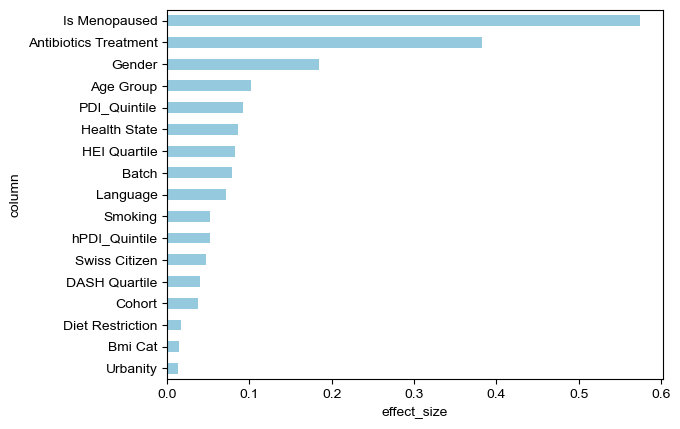

In [15]:
sns.barplot(
    x="effect_size", y="column", data=evires_beta_df, color="skyblue", width=0.5
)

## Merging all plots

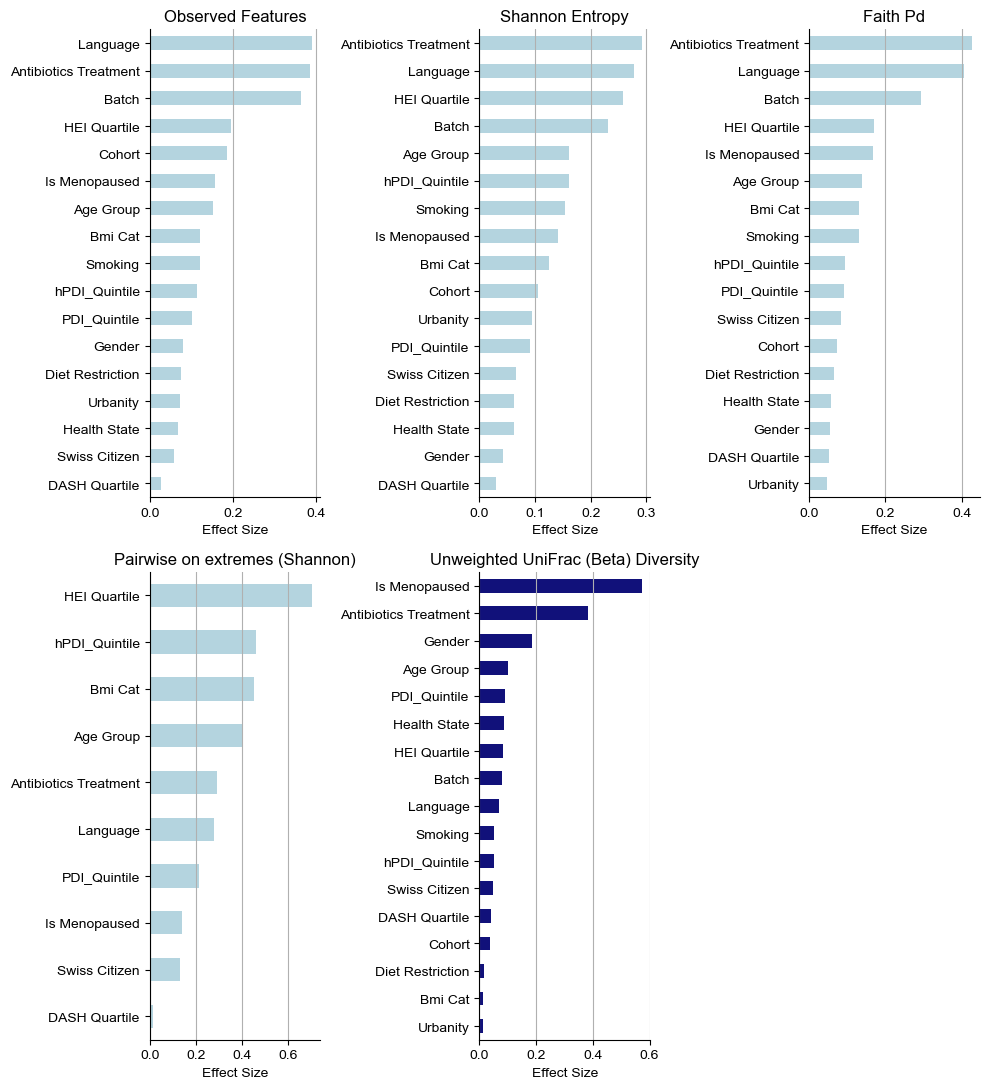

In [16]:
fig, ax = plt.subplots(
    2,
    3,
    figsize=(10, 11),
)
for i, diversity in enumerate(["observed_features", "shannon_entropy", "faith_pd"]):
    sns.barplot(
        data=evires_list[i],
        x="effect_size",
        y="column",
        color="lightblue",
        ax=ax[0, i],
        width=0.5,
    )
    ax[0, i].set_title(process_string(diversity))
    ax[0, i].set_xlabel("Effect Size")
    ax[0, i].set_ylabel("")
    ax[0, i].grid(axis="x")

sns.barplot(
    data=evires_pairwise_univariate,
    x="effect_size",
    y="column",
    color="lightblue",
    ax=ax[1, 0],
    width=0.5,
)
ax[1, 0].set_title("Pairwise on extremes (Shannon)")
ax[1, 0].set_xlabel("Effect Size")
ax[1, 0].set_ylabel("")
ax[1, 0].grid(axis="x")

sns.barplot(
    data=evires_beta_df,
    x="effect_size",
    y="column",
    color="darkblue",
    ax=ax[1, 1],
    width=0.5,
)
ax[1, 1].set_title("Unweighted UniFrac (Beta) Diversity")
ax[1, 1].set_xlabel("Effect Size")
ax[1, 1].set_ylabel("")
ax[1, 1].grid(axis="x")

ax[1, 2].axis("off")

plt.tight_layout()
sns.despine()

plt.savefig("../../figures/gut_diversity_analysis/evident_effect_sizes.png", dpi=300)